In [1]:
# MLP — Credit Card Fraud Detection
# Multi-Layer Perceptron baseline model: training, evaluation and threshold selection.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, auc
)
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

RANDOM_SEED = 42
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DATA_DIR = "/content/drive/MyDrive/SE4050_fraud_project/data/processed"

Mounted at /content/drive


In [3]:
train_df = pd.read_csv(f"{DATA_DIR}/train.csv")
val_df = pd.read_csv(f"{DATA_DIR}/val.csv")
test_df = pd.read_csv(f"{DATA_DIR}/test.csv")

FEATURE_COLS = [c for c in train_df.columns if c != "Class"]
X_train, y_train = train_df[FEATURE_COLS].values, train_df["Class"].values
X_val, y_val = val_df[FEATURE_COLS].values, val_df["Class"].values
X_test, y_test = test_df[FEATURE_COLS].values, test_df["Class"].values

print("Train/Val/Test shapes:", X_train.shape, X_val.shape, X_test.shape)

Train/Val/Test shapes: (198608, 30) (42559, 30) (42559, 30)


In [4]:
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", class_weight_dict)

def build_mlp(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss="binary_crossentropy",
                  metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])
    return model

model = build_mlp(X_train.shape[1])
model.summary()

Class weights: {0: np.float64(0.5008346908617742), 1: np.float64(300.012084592145)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353 (17.00 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 128 (512.00 B)

In [5]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc", mode="max", patience=8, restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50, batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[early_stop], verbose=1,
)

Epoch 1/50
776/776 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8878 - auc: 0.9478 - loss: 0.2736 - val_accuracy: 0.9822 - val_auc: 0.9826 - val_loss: 0.1185
Epoch 2/50
776/776 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9580 - auc: 0.9811 - loss: 0.1618 - val_accuracy: 0.9690 - val_auc: 0.9835 - val_loss: 0.1172
Epoch 3/50
776/776 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9591 - auc: 0.9862 - loss: 0.1431 - val_accuracy: 0.9671 - val_auc: 0.9833 - val_loss: 0.1050
Epoch 4/50
776/776 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9590 - auc: 0.9881 - loss: 0.1360 - val_accuracy: 0.9733 - val_auc: 0.9818 - val_loss: 0.0822
Epoch 5/50
776/776 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9630 - auc: 0.9907 - loss: 0.1204 - val_accuracy: 0.9738 - val_auc: 0.9827 - val_loss: 0.0753
Epoch 6/50
776/776 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9628 - auc: 0.9909 - loss: 0.1131 - val_accuracy: 0.9750 - val_auc: 0.9852 - val_loss: 0.0696
Epoch 7/50
776/776 ━━━━━━━━━━━━━━━━━━━━ 

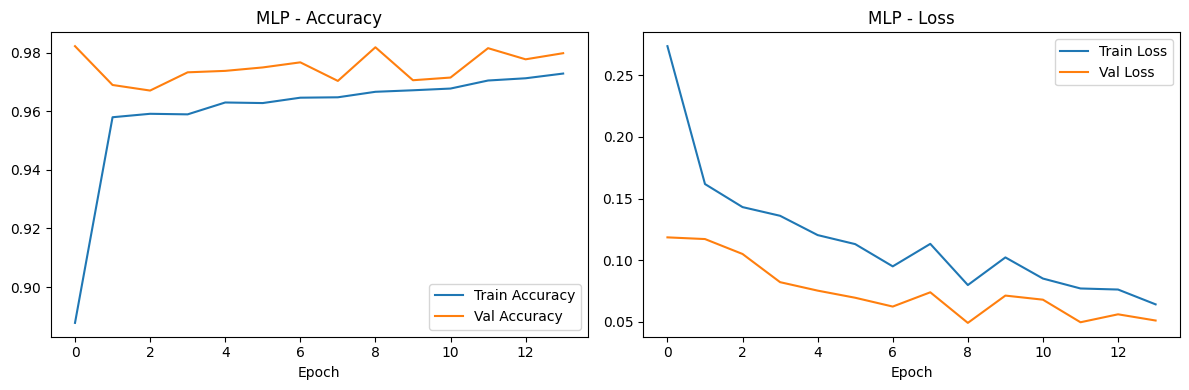

In [9]:
## Training Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["accuracy"], label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("MLP - Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(history.history["loss"], label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("MLP - Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig("mlp_training_curves.png", dpi=150)
plt.show()

In [8]:
## Threshold Selection (validation set, to avoid test-set leakage)
val_proba = model.predict(X_val).ravel()
vp, vr, vt = precision_recall_curve(y_val, val_proba)
vf1 = 2 * (vp * vr) / (vp + vr + 1e-9)
chosen_threshold = vt[np.argmax(vf1)]
print(f"Threshold chosen from validation set: {chosen_threshold:.4f}")

1330/1330 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Threshold chosen from validation set: 0.9979


In [10]:
## Final Test Evaluation
test_proba = model.predict(X_test).ravel()
y_pred = (test_proba >= chosen_threshold).astype(int)

print(classification_report(y_test, y_pred, target_names=["Normal", "Fraud"]))
roc_auc_val = roc_auc_score(y_test, test_proba)
print(f"ROC-AUC: {roc_auc_val:.4f}")

1330/1330 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     42488
       Fraud       0.80      0.79      0.79        71

    accuracy                           1.00     42559
   macro avg       0.90      0.89      0.90     42559
weighted avg       1.00      1.00      1.00     42559

ROC-AUC: 0.9595


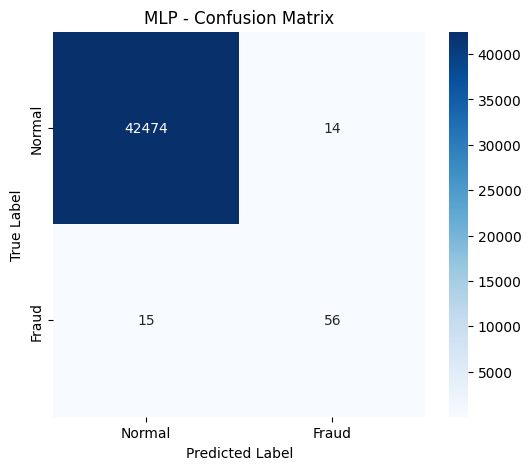

In [11]:
### Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal','Fraud'], yticklabels=['Normal','Fraud'])
plt.title('MLP - Confusion Matrix'); plt.xlabel('Predicted Label'); plt.ylabel('True Label')
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

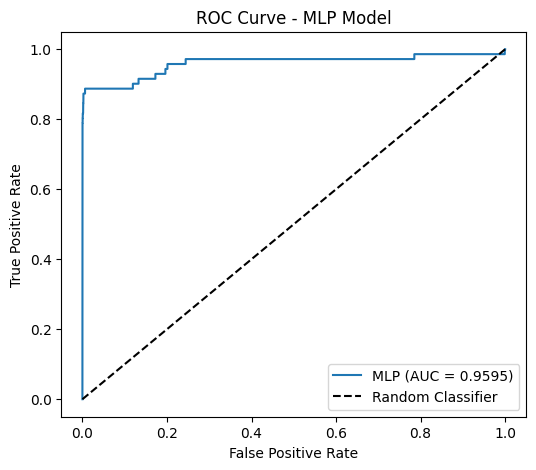

In [12]:
### ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'MLP (AUC = {roc_auc_val:.4f})')
plt.plot([0,1],[0,1],'k--', label='Random Classifier')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve - MLP Model'); plt.legend()
plt.savefig("roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()

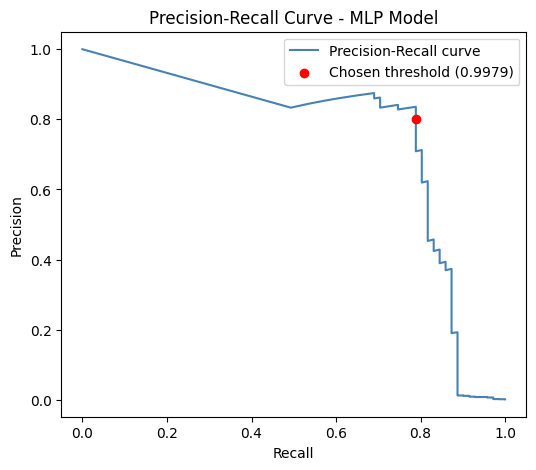

In [13]:
### Precision-Recall Curve
tp, tr, tt = precision_recall_curve(y_test, test_proba)
pr_auc_val = auc(tr, tp)
idx = np.argmin(np.abs(tt - chosen_threshold))
plt.figure(figsize=(6,5))
plt.plot(tr, tp, label='Precision-Recall curve', color='steelblue')
plt.scatter([tr[idx]], [tp[idx]], color='red', zorder=5, label=f'Chosen threshold ({chosen_threshold:.4f})')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve - MLP Model'); plt.legend()
plt.savefig("pr_curve.png", dpi=150, bbox_inches='tight')
plt.show()

In [14]:
## Metrics Summary
report = classification_report(y_test, y_pred, target_names=['Normal','Fraud'], output_dict=True)
metrics_row = {
    "Model": "MLP",
    "Accuracy": round((y_pred == y_test).mean(), 6),
    "Precision": round(report['Fraud']['precision'], 4),
    "Recall": round(report['Fraud']['recall'], 4),
    "F1-Score": round(report['Fraud']['f1-score'], 4),
    "ROC-AUC": round(roc_auc_val, 4),
    "PR-AUC": round(pr_auc_val, 4),
    "Threshold": round(chosen_threshold, 4)
}
metrics_df = pd.DataFrame([metrics_row])
metrics_df.to_csv("metrics.csv", index=False)
metrics_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Threshold
0,MLP,0.999319,0.8,0.7887,0.7943,0.9595,0.7488,0.9979
